In [464]:
import os
import rasterio as rio
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.path as mpth
from pathlib import Path

import Functions
import importlib

importlib.reload(Functions)

output_folder = Path('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents')
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Documents' / 'csv'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [465]:
moisture = pd.read_excel('/home/frank/Desktop/f.chiapperino_local'
                        '/VALENCIA/SCUOLA/App/Ground_Campaign_untouched/Flevoland_data/Data_25_fields/Average_Soil_moisture.xlsx',
                        header=1)
moisture.drop(columns=['Unnamed: 0','Unnamed: 1'], inplace=True)
moisture.set_index('Code',inplace=True)
moisture = moisture[moisture.index.notna()]

moisture_date = list(pd.to_datetime(moisture.columns))

moisture = moisture.reset_index().melt(id_vars='Code', var_name='Date', value_name='Moist_situ')
moisture.dropna(subset='Moist_situ', inplace=True)
moisture.set_index(pd.to_datetime(moisture['Date']),inplace=True)
moisture.drop(columns='Date',inplace=True)

corn = moisture[moisture['Code']==2294423.0]
display( corn)

,Code,Moist_situ
Date,,
2017-05-18,2294423.0,19.21250
2017-05-23,2294423.0,15.21875
2017-06-08,2294423.0,22.86875
2017-06-23,2294423.0,12.39375
2017-06-27,2294423.0,24.34375
2017-07-13,2294423.0,29.67500
2017-07-17,2294423.0,32.68750
2017-08-02,2294423.0,32.68750
2017-08-16,2294423.0,27.41250


In [466]:
from scipy.interpolate import pchip_interpolate

lista_dataframe_puliti = []
for c in moisture['Code'].unique():

    df = moisture[moisture['Code'] == c].copy()
    raggio_date_giornaliero = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    df = df.reindex(raggio_date_giornaliero)
    df.reset_index(names='Date', inplace=True)
    df['Code'] = c

    df['Umidita_Lineare_%'] = df['Moist_situ'].interpolate(method='linear')
    df['Umidita_PCHIP_%'] = df['Moist_situ'].interpolate(method='pchip')

    lista_dataframe_puliti.append(df)

df_generale = pd.concat(lista_dataframe_puliti, ignore_index=True)

df_generale = df_generale[['Date', 'Code', 'Moist_situ', 'Umidita_Lineare_%', 'Umidita_PCHIP_%']]
df_generale.sort_values(by=['Code', 'Date'], inplace=True, ignore_index=True)

display(df_generale[df_generale['Code'] == 1545384])

,Date,Code,Moist_situ,Umidita_Lineare_%,Umidita_PCHIP_%
0,2017-05-17,1545384.0,14.7875,14.787500,14.787500
1,2017-05-18,1545384.0,NaN,15.353125,15.409014
2,2017-05-19,1545384.0,NaN,15.918750,16.020748
3,2017-05-20,1545384.0,NaN,16.484375,16.613271
4,2017-05-21,1545384.0,NaN,17.050000,17.177150
...,...,...,...,...,...
117,2017-09-11,1545384.0,NaN,30.918750,30.308482
118,2017-09-12,1545384.0,NaN,31.673437,31.154040
119,2017-09-13,1545384.0,NaN,32.428125,32.054791
120,2017-09-14,1545384.0,NaN,33.182812,32.989641


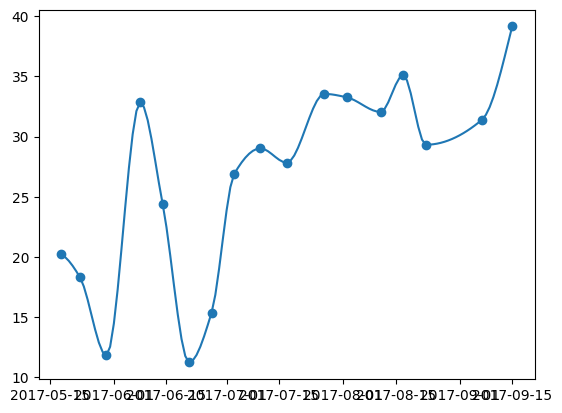

In [467]:
plt.plot(df_generale[df_generale['Code'] == 2081267]['Date'], df_generale[df_generale['Code'] == 2081267]['Umidita_PCHIP_%'])
plt.scatter(df_generale[df_generale['Code'] ==  2081267]['Date'], df_generale[df_generale['Code']==2081267]['Moist_situ'])

In [468]:
sigma_TM = pd.DataFrame(pd.read_csv(input_path / 'TimeSeries_sigma.csv'))
sigma_TM['Date'] = pd.to_datetime(sigma_TM['Date'])
sigma_TM.drop(sigma_TM[sigma_TM['mean'] == 0].index,inplace=True)

sigma_TM = sigma_TM.sort_values(by=['Code', 'Band', 'Date'])

display(sigma_TM)

,Code,Date_Band,mean,std,Date,Band,Name,Type
1298,1545384,20170104_VH,-15.490180,1.038437,2017-01-04,VH,DB_SB2_C,Potatoes
1300,1545384,20170110_VH,-14.146261,1.136036,2017-01-10,VH,DB_SB2_C,Potatoes
1302,1545384,20170116_VH,-20.622658,0.922879,2017-01-16,VH,DB_SB2_C,Potatoes
1304,1545384,20170122_VH,-22.050701,0.694627,2017-01-22,VH,DB_SB2_C,Potatoes
1306,1545384,20170128_VH,-16.818918,0.731224,2017-01-28,VH,DB_SB2_C,Potatoes
...,...,...,...,...,...,...,...,...
935,2278835,20171206_VV,-6.205426,0.920910,2017-12-06,VV,PVD-M-C,Corn
937,2278835,20171212_VV,-11.775089,0.645342,2017-12-12,VV,PVD-M-C,Corn
939,2278835,20171218_VV,-5.921874,1.043583,2017-12-18,VV,PVD-M-C,Corn
941,2278835,20171224_VV,-6.724238,1.070252,2017-12-24,VV,PVD-M-C,Corn


In [469]:
sigma_TM = pd.merge(
    sigma_TM, 
    df_generale, 
    on=['Code', 'Date'], 
    how='right' 
).dropna(subset='mean')
display(sigma_TM)

,Code,Date_Band,mean,std,Date,Band,Name,Type,Moist_situ,Umidita_Lineare_%,Umidita_PCHIP_%
5,1545384.0,20170522_VH,-25.417510,0.981700,2017-05-22,VH,DB_SB2_C,Potatoes,NaN,17.615625,17.702953
6,1545384.0,20170522_VV,-16.278032,1.370943,2017-05-22,VV,DB_SB2_C,Potatoes,NaN,17.615625,17.702953
12,1545384.0,20170528_VH,-22.028130,1.283643,2017-05-28,VH,DB_SB2_C,Potatoes,NaN,19.952734,20.562807
13,1545384.0,20170528_VV,-14.739777,1.149636,2017-05-28,VV,DB_SB2_C,Potatoes,NaN,19.952734,20.562807
19,1545384.0,20170603_VH,-19.479914,0.890061,2017-06-03,VH,DB_SB2_C,Potatoes,NaN,22.078516,23.020128
...,...,...,...,...,...,...,...,...,...,...,...
2806,2278835.0,20170901_VV,-11.232622,0.884906,2017-09-01,VV,PVD-M-C,Corn,NaN,26.815000,26.741838
2812,2278835.0,20170907_VH,-17.050945,0.822061,2017-09-07,VH,PVD-M-C,Corn,26.925,26.925000,26.925000
2813,2278835.0,20170907_VV,-10.962885,0.753886,2017-09-07,VV,PVD-M-C,Corn,26.925,26.925000,26.925000
2819,2278835.0,20170913_VH,-17.256754,1.036561,2017-09-13,VH,PVD-M-C,Corn,NaN,33.468750,32.655167


In [470]:
sigma_TM['diff_mean'] = -sigma_TM.groupby(['Code', 'Band'])['mean'].diff(periods=-1)
sigma_TM['diff_lin'] = 10 ** (sigma_TM['diff_mean']/10)
sigma_TM.insert(len(sigma_TM.columns)-1, 'Moist_situ', sigma_TM.pop('Moist_situ'))

sigma_TM = sigma_TM.sort_values(by=['Code', 'Band', 'Date']).reset_index(drop=True)
display(sigma_TM[sigma_TM['Code']==1545384.0])

,Code,Date_Band,mean,std,Date,Band,Name,Type,Umidita_Lineare_%,Umidita_PCHIP_%,diff_mean,diff_lin,Moist_situ
0,1545384.0,20170522_VH,-25.417510,0.981700,2017-05-22,VH,DB_SB2_C,Potatoes,17.615625,17.702953,3.389380,2.182418,NaN
1,1545384.0,20170528_VH,-22.028130,1.283643,2017-05-28,VH,DB_SB2_C,Potatoes,19.952734,20.562807,2.548216,1.798132,NaN
2,1545384.0,20170603_VH,-19.479914,0.890061,2017-06-03,VH,DB_SB2_C,Potatoes,22.078516,23.020128,4.836104,3.045162,NaN
3,1545384.0,20170609_VH,-14.643810,1.127511,2017-06-09,VH,DB_SB2_C,Potatoes,22.547321,23.497828,-2.752335,0.530599,NaN
4,1545384.0,20170615_VH,-17.396145,0.856844,2017-06-15,VH,DB_SB2_C,Potatoes,14.731250,14.731250,0.539885,1.132370,14.73125
5,1545384.0,20170627_VH,-16.856260,1.061146,2017-06-27,VH,DB_SB2_C,Potatoes,11.993750,11.993750,2.260631,1.682919,11.99375
6,1545384.0,20170703_VH,-14.595629,0.875960,2017-07-03,VH,DB_SB2_C,Potatoes,25.218750,25.218750,-1.365139,0.730274,25.21875
7,1545384.0,20170709_VH,-15.960768,0.849283,2017-07-09,VH,DB_SB2_C,Potatoes,24.086250,23.995650,0.243426,1.057652,NaN
8,1545384.0,20170715_VH,-15.717342,1.097161,2017-07-15,VH,DB_SB2_C,Potatoes,24.500000,24.500000,-0.477507,0.895879,NaN
9,1545384.0,20170721_VH,-16.194849,0.786668,2017-07-21,VH,DB_SB2_C,Potatoes,25.436250,25.560158,1.040939,1.270849,NaN


In [471]:
def alpha_recursion(ssm_arr, ratio_arr, win=4):

    ssm_ret = ssm_arr.copy().astype(float)
    
    for b in range(0, len(ssm_ret), win):
        for passo in range(1, win):
    
            i = b + passo
            if i >= len(ssm_ret):
                break
            if not np.isnan(ssm_ret[i-1]) and not np.isnan(ratio_arr[i]):
                ssm_ret[i] = ratio_arr[i-1] * ssm_ret[i-1]
            else:
                continue
    
    return ssm_ret

sigma_TM['SSM_retrieved'] = sigma_TM.groupby(['Code', 'Band'], group_keys=False).apply(
    lambda g: pd.Series(alpha_recursion(g['Umidita_PCHIP_%'].values, g['diff_lin'].values), index=g.index)
)

In [472]:
display(sigma_TM)

,Code,Date_Band,mean,std,Date,Band,Name,Type,Umidita_Lineare_%,Umidita_PCHIP_%,diff_mean,diff_lin,Moist_situ,SSM_retrieved
0,1545384.0,20170522_VH,-25.417510,0.981700,2017-05-22,VH,DB_SB2_C,Potatoes,17.615625,17.702953,3.389380,2.182418,NaN,17.702953
1,1545384.0,20170528_VH,-22.028130,1.283643,2017-05-28,VH,DB_SB2_C,Potatoes,19.952734,20.562807,2.548216,1.798132,NaN,38.635250
2,1545384.0,20170603_VH,-19.479914,0.890061,2017-06-03,VH,DB_SB2_C,Potatoes,22.078516,23.020128,4.836104,3.045162,NaN,69.471284
3,1545384.0,20170609_VH,-14.643810,1.127511,2017-06-09,VH,DB_SB2_C,Potatoes,22.547321,23.497828,-2.752335,0.530599,NaN,211.551314
4,1545384.0,20170615_VH,-17.396145,0.856844,2017-06-15,VH,DB_SB2_C,Potatoes,14.731250,14.731250,0.539885,1.132370,14.73125,14.731250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,2278835.0,20170820_VV,-11.036517,1.013179,2017-08-20,VV,PVD-M-C,Corn,27.250000,27.250000,-0.675594,0.855935,NaN,27.934773
642,2278835.0,20170826_VV,-11.712111,0.816160,2017-08-26,VV,PVD-M-C,Corn,26.705000,26.659408,0.479489,1.116732,NaN,23.910339
643,2278835.0,20170901_VV,-11.232622,0.884906,2017-09-01,VV,PVD-M-C,Corn,26.815000,26.741838,0.269737,1.064079,NaN,26.701437
644,2278835.0,20170907_VV,-10.962885,0.753886,2017-09-07,VV,PVD-M-C,Corn,26.925000,26.925000,0.013563,1.003128,26.92500,26.925000


In [473]:
from scipy import stats

results_regression = []

for (codice, banda, name,typ), gruppo in sigma_TM.groupby(['Code', 'Band', 'Name', 'Type']):   

    moist_situ = gruppo['Umidita_PCHIP_%'].values
    SSM_ret = gruppo['SSM_retrieved'].values

    if len(moist_situ) > 2:

        slope, intercept, r_value, p_value, std_err = stats.linregress(moist_situ, SSM_ret)        
        y_pred = slope * moist_situ + intercept
        
        residui = SSM_ret - y_pred
        
        rmsre = np.sqrt(np.mean(residui ** 2))
        
        results_regression.append({
            'Code': codice,
            'Name': name,
            'Band': banda,
            'Type': typ,
            'N_points': len(moist_situ),
            'R_Pearson': r_value,
            'R_2': r_value ** 2,
            'P_value': p_value,
            'Slope': slope,
            'Intercept': intercept,
            'RMSRE': rmsre
        })

df_statistiche = pd.DataFrame(results_regression)
df_statistiche.sort_values('R_2', ascending=False, inplace=True)
display(df_statistiche)

filename = "moisture_reg_xfield.csv"
output_path = output_folder / 'csv' / filename

df_statistiche.to_csv(output_path ,index=False, sep=';', decimal='.')

,Code,Name,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
14,1824038.0,AKW_G2_C,VH,Grassland,17,0.732923,0.537176,0.000817,1.525865,-9.764875,8.962983
15,1824038.0,AKW_G2_C,VV,Grassland,17,0.704675,0.496567,0.001585,2.079079,-19.596580,13.247671
27,1936135.0,AKW_T_C,VV,Wheat,17,0.654238,0.428027,0.004382,0.941038,5.148253,7.017261
16,1841223.0,DB_T_C,VH,Wheat,18,0.548332,0.300668,0.018465,0.945630,3.936146,7.440353
11,1697690.0,SB8_ER_C,VV,Grassland,10,-0.538737,0.290237,0.108106,-1.912686,94.097360,6.872784
33,2081268.0,RBW_A_C,VV,Potatoes,18,0.528154,0.278947,0.024256,0.996382,3.044475,8.008254
26,1936135.0,AKW_T_C,VH,Wheat,17,0.522567,0.273077,0.031390,0.986539,4.519074,10.383042
7,1631664.0,AKW-G1_C,VV,Grassland,17,0.518512,0.268855,0.032970,0.960576,4.921883,7.321842
31,2081267.0,RBW_T_C,VV,Wheat,18,0.486227,0.236417,0.040758,0.797142,11.042051,9.368401
10,1697690.0,SB8_ER_C,VH,Grassland,10,-0.476874,0.227409,0.163447,-1.648189,86.368607,6.980518


In [474]:
from scipy import stats

results_regression_VV = []

for (codice, banda, name,typ), gruppo in sigma_TM.groupby(['Code', 'Band', 'Name', 'Type']):   

    VV = gruppo['mean'].values
    SSM_ret = gruppo['SSM_retrieved'].values

    if len(VV) > 2:

        slope, intercept, r_value, p_value, std_err = stats.linregress(VV, SSM_ret)        
        y_pred = slope * VV + intercept
        
        residui = SSM_ret - y_pred
        
        rmsre = np.sqrt(np.mean(residui ** 2))
        
        results_regression_VV.append({
            'Code': codice,
            'Name': name,
            'Band': banda,
            'Type': typ,
            'N_points': len(VV),
            'R_Pearson': r_value,
            'R_2': r_value ** 2,
            'P_value': p_value,
            'Slope': slope,
            'Intercept': intercept,
            'RMSRE': rmsre
        })

df_statistiche_VV = pd.DataFrame(results_regression)
df_statistiche_VV.sort_values('R_2', ascending=False, inplace=True)
display(df_statistiche_VV)




,Code,Name,Band,Type,N_points,R_Pearson,R_2,P_value,Slope,Intercept,RMSRE
14,1824038.0,AKW_G2_C,VH,Grassland,17,0.732923,0.537176,0.000817,1.525865,-9.764875,8.962983
15,1824038.0,AKW_G2_C,VV,Grassland,17,0.704675,0.496567,0.001585,2.079079,-19.596580,13.247671
27,1936135.0,AKW_T_C,VV,Wheat,17,0.654238,0.428027,0.004382,0.941038,5.148253,7.017261
16,1841223.0,DB_T_C,VH,Wheat,18,0.548332,0.300668,0.018465,0.945630,3.936146,7.440353
11,1697690.0,SB8_ER_C,VV,Grassland,10,-0.538737,0.290237,0.108106,-1.912686,94.097360,6.872784
33,2081268.0,RBW_A_C,VV,Potatoes,18,0.528154,0.278947,0.024256,0.996382,3.044475,8.008254
26,1936135.0,AKW_T_C,VH,Wheat,17,0.522567,0.273077,0.031390,0.986539,4.519074,10.383042
7,1631664.0,AKW-G1_C,VV,Grassland,17,0.518512,0.268855,0.032970,0.960576,4.921883,7.321842
31,2081267.0,RBW_T_C,VV,Wheat,18,0.486227,0.236417,0.040758,0.797142,11.042051,9.368401
10,1697690.0,SB8_ER_C,VH,Grassland,10,-0.476874,0.227409,0.163447,-1.648189,86.368607,6.980518
